In [1]:
import pandas as pd
import numpy as np

In [4]:
digits_data_train = pd.read_csv("train.csv")

In [5]:
digits_data_train

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
y = digits_data_train['label']
X = digits_data_train.drop("label",axis = 1)

In [19]:
X

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
y

0        1
1        0
2        1
3        4
4        0
        ..
41995    0
41996    1
41997    7
41998    6
41999    9
Name: label, Length: 42000, dtype: int64

In [21]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)

In [22]:
#SVM
from sklearn.svm import SVC
svm = SVC()

In [23]:
svm.fit(X_train,y_train)

SVC()

In [28]:
svm.score(X_test,y_test)

0.9726984126984127

In [29]:
#Random Forest Classifier 
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()

In [30]:
rfc.fit(X_train,y_train)

RandomForestClassifier()

In [31]:
rfc.score(X_test,y_test)

0.9620634920634921

In [32]:
from sklearn.neighbors import KNeighborsClassifier

In [33]:
knn = KNeighborsClassifier()

In [34]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [35]:
knn.score(X_test,y_test)

0.9650793650793651

In [36]:
#actual data

In [37]:
test = pd.read_csv("test.csv")

In [39]:
predictions = knn.predict(test)

In [42]:
np.arange(1,len(predictions))
len(predictions)

28000

In [43]:
predictions_df = pd.DataFrame(predictions,index = np.arange(1,len(predictions)+1))

In [45]:
predictions_df = predictions_df.rename_axis(index = "ImageId")
predictions_df = predictions_df.rename({0:"Label"},axis = 1)

In [47]:
predictions_df.to_csv("Output.csv")

In [48]:
predictions_1_df = svm.predict(test)

In [49]:
predictions_1_df

array([2, 0, 9, ..., 3, 9, 2], dtype=int64)

In [51]:
predictions_1_df = pd.DataFrame(predictions_1_df,index = np.arange(1,len(predictions_1_df)+1))

In [52]:
predictions_1_df = predictions_1_df.rename_axis(index = "ImageId")
predictions_1_df = predictions_1_df.rename({0:"Label"},axis = 1)

In [54]:
predictions_1_df.to_csv("Output1.csv")

In [57]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,knn.predict(X_test))

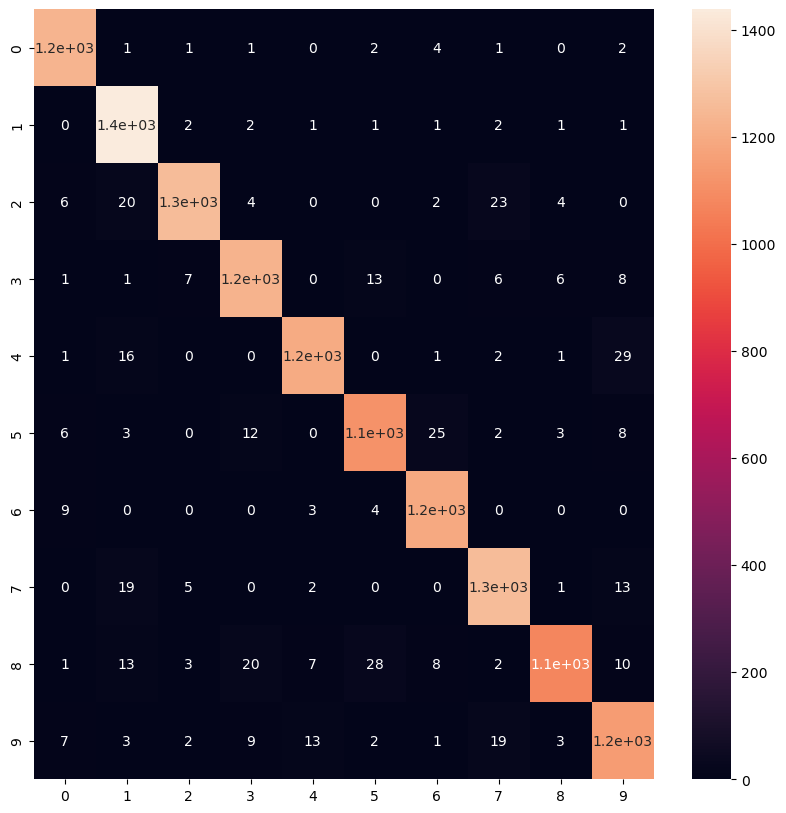

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10,10))
sns.heatmap(cm, annot = True)
plt.show()